# Интеллектуальный анализ данных – весна 2025
# Домашнее задание 6: классификация текстов

Правила:



*   Домашнее задание оценивается в 10 баллов.
*   Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.
*  Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.
*  Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.
*  Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.
* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

В этом домашнем задании вам предстоит построить классификатор текстов.

Будем предсказывать эмоциональную окраску твиттов о коронавирусе.



In [1]:
import numpy as np
import pandas as pd
from typing import  List
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation

In [2]:
df = pd.read_csv('tweets_coronavirus.csv', encoding='latin-1')
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
31937,43082,88034,India,12-04-2020,"@BusinessDubai All the planning, forecasts, ai...",Extremely Negative
8764,14448,59400,"Melbourne, Australia",20-03-2020,"People stop panic buying, this is what you do ...",Negative
7888,13390,58342,"Sunny Isles Beach, FL",20-03-2020,@Uber Your drivers are still driving tourists ...,Positive
12918,19461,64413,Lagos,22-03-2020,@muhdsumar @cchidume @tomabuba @nickikaruechhe...,Extremely Negative


Для каждого твитта указано:


*   UserName - имя пользователя, заменено на целое число для анонимности
*   ScreenName - отображающееся имя пользователя, заменено на целое число для анонимности
*   Location - местоположение
*   TweetAt - дата создания твитта
*   OriginalTweet - текст твитта
*   Sentiment - эмоциональная окраска твитта (целевая переменная)



## Задание 1 Подготовка (0.5 балла)

Целевая переменная находится в колонке `Sentiment`.  Преобразуйте ее таким образом, чтобы она стала бинарной: 1 - если у твитта положительная или очень положительная эмоциональная окраска и 0 - если отрицательная или очень отрицательная.

In [3]:
# -- YOUR CODE HERE --
df['Sentiment'] = df['Sentiment'].apply(
    lambda x: 1 if x in ['Positive', 'Extremely Positive'] else 0
)

In [4]:
df.sample(4)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
16173,23490,68442,Shanghai,24-03-2020,Fight the #coronavirus. As a response effort t...,1
25506,35041,79993,NaN,06-04-2020,@airvistara @IndiGo6E @narendramodi Tickets pr...,1
10323,16330,61282,NaN,21-03-2020,@nuernberg_de few grocery stores have increase...,0
8252,13825,58777,Dubai,20-03-2020,endless page after page of greedy people selli...,0


Сбалансированы ли классы?

In [5]:
# -- YOUR CODE HERE --
class_counts = df['Sentiment'].value_counts()
print(class_counts)

Sentiment
1    18046
0    15398
Name: count, dtype: int64


In [6]:
imbalance_ratio = class_counts[0] / class_counts[1]
print(f"Соотношение классов: {imbalance_ratio:.1f}:1")

Соотношение классов: 0.9:1


**Ответ:** 
да, сбалансированы

Выведете на экран информацию о пропусках в данных. Если пропуски присутствуют заполните их строкой 'Unknown'.

In [7]:
# -- YOUR CODE HERE --
missing_values = df.isnull().sum()
print(missing_values)

UserName            0
ScreenName          0
Location         7049
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64


In [8]:
df= df.fillna('Unknown')
missing_values = df.isnull().sum()
print(missing_values)

UserName         0
ScreenName       0
Location         0
TweetAt          0
OriginalTweet    0
Sentiment        0
dtype: int64


Разделите данные на обучающие и тестовые в соотношении 7 : 3 и укажите `random_state=0`

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.3, random_state=0)

## Задание 2 Токенизация (3 балла)

Постройте словарь на основе обучающей выборки и посчитайте количество встреч каждого токена с использованием самой простой токенизации - деления текстов по пробельным символам и приведения токенов в нижний регистр.

In [10]:
# -- YOUR CODE HERE --
from collections import defaultdict
import pandas as pd

In [11]:
from collections import Counter
tweets = train['OriginalTweet']
all_tokens = []
for tweet in tweets:
    tokens = tweet.lower().split()
    all_tokens.extend(tokens)
token_counts = Counter(all_tokens)
print("Словарь токенов и их частот:")
token_counts.most_common(20)

Словарь токенов и их частот:


[('the', 26815),
 ('to', 23373),
 ('and', 14684),
 ('of', 13012),
 ('a', 11737),
 ('in', 11198),
 ('for', 8566),
 ('#coronavirus', 8223),
 ('is', 7383),
 ('are', 7050),
 ('you', 5467),
 ('on', 5452),
 ('i', 5340),
 ('at', 4642),
 ('this', 4581),
 ('with', 4063),
 ('prices', 3891),
 ('food', 3820),
 ('we', 3787),
 ('have', 3770)]

Какой размер словаря получился?

In [12]:
# -- YOUR CODE HERE --
vocab_size = len(token_counts)
print(f"Размер словаря: {vocab_size}")

Размер словаря: 79755


Выведите 10 самых популярных токенов с количеством встреч каждого из них. Объясните, почему именно эти токены в топе.

In [13]:
# -- YOUR CODE HERE --
token_counts.most_common(10)

[('the', 26815),
 ('to', 23373),
 ('and', 14684),
 ('of', 13012),
 ('a', 11737),
 ('in', 11198),
 ('for', 8566),
 ('#coronavirus', 8223),
 ('is', 7383),
 ('are', 7050)]

**Ответ:** Самыми популярными словами являются артикли и предлоги, а также глагол to be. Все эти слова являются самыми распространенными, так как используюся в большинстве высказываний вне зависимости от их контекста. Также наиболее популярным является coronovirus, так как датасет посвящен ему.

Удалите стоп-слова из словаря и выведите новый топ-10 токенов (и количество встреч) по популярности.  Что можно сказать  о нем?

In [14]:
import nltk
from nltk.corpus import stopwords

# -- YOUR CODE HERE --
stop_words = set(stopwords.words('english'))
filtered_token_counts = {token: count for token, count in token_counts.items() if token not in stop_words}
token_counts = Counter(filtered_token_counts)
token_counts.most_common(10)

[('#coronavirus', 8223),
 ('prices', 3891),
 ('food', 3820),
 ('grocery', 3469),
 ('supermarket', 3288),
 ('people', 3175),
 ('covid-19', 3173),
 ('store', 3155),
 ('#covid19', 2471),
 ('&amp;', 2314)]

**Ответ:** Теперь наиболее популярными стали слова, которые напрямую связаны с темой датасета (coronovirus, covid19). Также популярны слова, такике как food, grocery, supermarket и др., так как именно вопрос продовольствия и цен (prices) во времена пандемии вставал наиболее остро.&amp – это результат избыточного экранирования HTML-сущности амперсанда (&).

Также выведите 20 самых непопулярных слов (если самых непопулярных слов больше, выведите любые 20 из них) Почему эти токены непопулярны, требуется ли как-то дополнительно работать с ними?

In [15]:
# -- YOUR CODE HERE --
least_common = token_counts.most_common()[:-21:-1]
least_common

[('https://t.co/7j2y3rsld9', 1),
 ('@680news', 1),
 ('@torontopearson', 1),
 ('nothing...', 1),
 ('flew', 1),
 ('wage!', 1),
 ('renewing', 1),
 ('playersã\x82â\x92', 1),
 ('subsidise', 1),
 ('non-playing', 1),
 ('premiership', 1),
 ('https://t.co/iaek4fwsgz', 1),
 ('@srinivasiyc', 1),
 ('https://t.co/zjcl195vqs', 1),
 ('#southkerry', 1),
 ('#skelligcoast2kms', 1),
 ('@skelligsix18', 1),
 ('closer!)', 1),
 ('coast!', 1),
 ('skellig', 1)]

**Ответ:** Примерами таких токенов служат ссылки, специфические хэштеги и др. На эмоциональную окраску они мало влияют как минимум в силу того, что встречаются единожды

Теперь воспользуемся токенайзером получше - TweetTokenizer из библиотеки nltk. Примените его и посмотрите на топ-10 популярных слов. Чем он отличается от топа, который получался раньше? Почему?

In [16]:
from nltk.tokenize import TweetTokenizer
# -- YOUR CODE HERE --
import itertools

tokenizer = TweetTokenizer()
top_10_words = Counter(
    itertools.chain.from_iterable(
        tokenizer.tokenize(tweet) 
        for tweet in df['OriginalTweet']
    )
).most_common(10)

top_10_words

[('the', 34781),
 ('.', 34284),
 ('to', 32812),
 (',', 25142),
 ('and', 20439),
 ('of', 18429),
 ('a', 15679),
 ('in', 15143),
 ('?', 13730),
 ('for', 11722)]

**Ответ:** Теперь помимо артиклей и предлогов в наиболее популярные токены стали входить знаки препинания

Удалите из словаря стоп-слова и пунктуацию, посмотрите на новый топ-10 слов с количеством встреч, есть ли теперь в нем что-то не похожее на слова?

In [17]:
from string import punctuation

# -- YOUR CODE HERE --

tokenizer = TweetTokenizer()
stop_words = set(nltk.corpus.stopwords.words('english'))
punctuation_set = set(punctuation)
token_counts_clean = Counter()

for tweet in train['OriginalTweet']:
    tokens = tokenizer.tokenize(tweet)
    tokens = [
        token for token in tokens
        if token not in stop_words
        and token not in punctuation_set
    ]
    token_counts_clean.update(tokens)
token_counts_clean.most_common(10)

[('Â', 7415),
 ('\x82', 7311),
 ('19', 7167),
 ('#coronavirus', 7143),
 ('I', 5235),
 ('\x92', 4372),
 ('prices', 4281),
 ('COVID', 4218),
 ('food', 3795),
 ('store', 3691)]

**Ответ:** В данный топ входят слова известные ранее, а также символы, которые связаны с ошибкой в кодировке

Скорее всего в некоторых топах были неотображаемые символы или отдельные буквы не латинского алфавита. Уберем их: удалите из словаря токены из одного символа, позиция которого в таблице Unicode 128 и более (`ord(x) >= 128`)

Выведите топ-10 самых популярных и топ-20 непопулярных слов. Чем полученные топы отличаются от итоговых топов, полученных при использовании токенизации по пробелам? Что теперь лучше, а что хуже?

In [18]:
# -- YOUR CODE HERE --
token_counts_final = Counter()
for token, count in token_counts.items():
    if len(token) == 1 and any(ord(char) >= 128 for char in token):
        continue
    token_counts_final[token] = count
token_counts_final.most_common(10)

[('#coronavirus', 8223),
 ('prices', 3891),
 ('food', 3820),
 ('grocery', 3469),
 ('supermarket', 3288),
 ('people', 3175),
 ('covid-19', 3173),
 ('store', 3155),
 ('#covid19', 2471),
 ('&amp;', 2314)]

In [19]:
least_common_final = token_counts_final.most_common()[:-21:-1]
least_common_final

[('https://t.co/7j2y3rsld9', 1),
 ('@680news', 1),
 ('@torontopearson', 1),
 ('nothing...', 1),
 ('flew', 1),
 ('wage!', 1),
 ('renewing', 1),
 ('playersã\x82â\x92', 1),
 ('subsidise', 1),
 ('non-playing', 1),
 ('premiership', 1),
 ('https://t.co/iaek4fwsgz', 1),
 ('@srinivasiyc', 1),
 ('https://t.co/zjcl195vqs', 1),
 ('#southkerry', 1),
 ('#skelligcoast2kms', 1),
 ('@skelligsix18', 1),
 ('closer!)', 1),
 ('coast!', 1),
 ('skellig', 1)]

**Ответ:** Больше нет неотображаемых смиволов, смысловая нагрузка топов осталась прежней.

Выведите топ-10 популярных хештегов (токены, первые символы которых - #) с количеством встреч. Что можно сказать о них?

In [20]:
# -- YOUR CODE HERE --
hashtag_counts = Counter({
    token: count for token, count in token_counts_final.items() if token.startswith('#')
})
hashtag_counts.most_common(10)

[('#coronavirus', 8223),
 ('#covid19', 2471),
 ('#covid_19', 1660),
 ('#covid2019', 915),
 ('#toiletpaper', 691),
 ('#socialdistancing', 427),
 ('#coronacrisis', 423),
 ('#covid?19', 418),
 ('#coronaviruspandemic', 245),
 ('#pandemic', 232)]

**Ответ:** Большинство хэштегов связаны с основной темой датасета: короновирусом, остальные два - самоизоляция и туалетная бумага являются вытекающими проблемами, волновавшими людей.

То же самое проделайте для ссылок на сайт https://t.co Сравнима ли популярность ссылок с популярностью хештегов? Будет ли информация о ссылке на конкретную страницу полезна?

In [21]:
# -- YOUR CODE HERE --
link_counts = Counter({
    token: count for token, count in token_counts_final.items() if token.startswith('https://t.co')
})
link_counts.most_common(10)

[('https://t.co/oxa7swtond', 5),
 ('https://t.co/gp3eusapl8', 4),
 ('https://t.co/deftrui1pfã\x82â', 3),
 ('https://t.co/wrlhyzizaa', 3),
 ('https://t.co/kuwipf1kqw', 3),
 ('https://t.co/zjnrx6dkkn', 3),
 ('https://t.co/3gbbdpdjat', 3),
 ('https://t.co/e2znxajpre', 3),
 ('https://t.co/catkegayoy', 3),
 ('https://t.co/g63rp042ho', 3)]

**Ответ:** Хэштеги сильно популярнее ссылок, поэтому информация о ссылке на конкретную страницу не принесет большой пользы

Используем опыт предыдущих экспериментов и напишем собственный токенайзер, улучшив TweetTokenizer. Функция tokenize должна:



*   Привести текст в нижний регистр
*   Применить TweetTokenizer для  выделения токенов
*   Удалить стоп-слова, пунктуацию, токены из одного символа с позицией в таблице Unicode 128 и более,  ссылки на t.co



In [22]:
tokenizer = TweetTokenizer(
    preserve_case=False,
    strip_handles=False,
    reduce_len=False
)
def custom_tokenizer(text):
    text = text.lower()
    tokens = tokenizer.tokenize(text)
    filtered_tokens = []
    for token in tokens:
        if token in stop_words:
            continue
        if token in punctuation_set:
            continue
        if token.startswith(('http://', 'https://', 'www.')):
            continue
        if len(token) == 1 and ord(token) >= 128:
            continue
        filtered_tokens.append(token)
    return filtered_tokens

In [23]:
custom_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext')

['sample', 'text', '@sample_text', '#sampletext']

## Задание 3 Векторизация текстов (2 балла)

Обучите CountVectorizer с использованием custom_tokenizer в качестве токенайзера. Как размер полученного словаря соотносится с размером изначального словаря из начала задания 2?

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# -- YOUR CODE HERE --
cv = CountVectorizer(tokenizer=custom_tokenizer)
cv.fit(train['OriginalTweet'])


print(len(cv.vocabulary_))

C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


45286


**Ответ:** Этот словарь почти в два раза меньше того, который был получен в задании 2. Это может быть связано с тем, что значительную часть составляли ссылки, стоп-слова и нечитаемые символы и (ошибка кодировки)

Посмотрим на какой-нибудь конкретный твитт:

In [25]:
ind = 9023
twitt = train.iloc[ind]['OriginalTweet'], train.iloc[ind]['Sentiment']
twitt

('Nice one @SkyNews lets not panic but show ppl in france queueing for food!!! #CoronavirusOutbreak #COVID2019 brainless!! Ffs',
 np.int64(0))

Автор твитта не доволен ситуацией с едой во Франции и текст имеет резко негативную окраску.

Примените обученный CountVectorizer для векторизации данного текста, и попытайтесь определить самый важный токен и самый неважный токен (токен, компонента которого в векторе максимальна/минимальна, без учета 0). Хорошо ли они определились, почему?

In [26]:
# -- YOUR CODE HERE --
vector_twitt = cv.transform([twitt[0]])
print(vector_twitt)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 14 stored elements and shape (1, 45286)>
  Coords	Values
  (0, 1833)	1
  (0, 2046)	1
  (0, 16658)	1
  (0, 20553)	1
  (0, 26665)	1
  (0, 27042)	1
  (0, 27233)	1
  (0, 31568)	1
  (0, 34068)	1
  (0, 34677)	1
  (0, 35246)	1
  (0, 36402)	1
  (0, 37218)	1
  (0, 39907)	1


**Ответ:** Не получится определить самый важный или неавжный токен, так как все токены встречаются единожды, а частота является единственным условием

Теперь примените TfidfVectorizer и  определите самый важный/неважный токены. Хорошо ли определились, почему?

In [27]:
# -- YOUR CODE HERE --
from sklearn.feature_extraction.text import TfidfVectorizer
tv = TfidfVectorizer(tokenizer=custom_tokenizer)
tv.fit(train['OriginalTweet'])
tv_vector = tv.transform([twitt[0]])
print(tv_vector)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14 stored elements and shape (1, 45286)>
  Coords	Values
  (0, 1833)	0.22584265007428544
  (0, 2046)	0.16825192939361902
  (0, 16658)	0.31042634466284263
  (0, 20553)	0.3867641170466375
  (0, 26665)	0.3244741764513268
  (0, 27042)	0.11328893069250721
  (0, 27233)	0.32047314046539654
  (0, 31568)	0.30121070136861045
  (0, 34068)	0.2542729176022132
  (0, 34677)	0.16306722855395073
  (0, 35246)	0.14759470306326164
  (0, 36402)	0.2550064610386691
  (0, 37218)	0.35434556333216544
  (0, 39907)	0.24406492401820118


In [28]:
tv_array = tv_vector.toarray()[0]
max_index = tv_array.argmax()
inverse_vocab = {i: word for word, i in tv.vocabulary_.items()}
most_important = inverse_vocab[max_index]
most_important_score = tv_array[max_index]
non_zero_indices = np.where(tv_array > 0)[0]
if len(non_zero_indices) > 0:
    min_index = non_zero_indices[tv_array[non_zero_indices].argmin()]
    least_important = inverse_vocab[min_index]
    least_important_score = tv_array[min_index]
else:
    least_important = None
    least_important_score = None
print(f"Самый важный токен: '{most_important}' (вес: {most_important_score:.4f})")
print(f"Самый неважный токен: '{least_important}' (вес: {least_important_score:.4f})")

Самый важный токен: 'brainless' (вес: 0.3868)
Самый неважный токен: 'food' (вес: 0.1133)


Найдите какой-нибудь положительно окрашенный твитт, где TfidfVectorizer хорошо (полезно для определения окраски) выделяет важный токен, поясните пример.

*Подсказка:* явно положительные твитты можно искать при помощи положительных слов (good, great, amazing и т. д.)

In [29]:
train[train['OriginalTweet'].apply(lambda x: 'great' in x) & (train['Sentiment'] == 1)].head(30)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
192,4035,48987,"San Diego, CA",16-03-2020,"What's a good way to support grocery store, me...",1
4066,8742,53694,"Adelaide, South Australia",18-03-2020,BREAKING: WeÃÂre giving supermarkets the opt...,1
342,4219,49171,"Boston, MA",16-03-2020,[THREAD] China's role in wildlife trade should...,1
21883,30511,75463,London,02-04-2020,Coronavirus career pivots: 'I now work in a su...,1
23519,32529,77481,"Moulton, England",05-04-2020,Well done James great front of store before we...,1
1996,6229,51181,"Manchester, UK",17-03-2020,"So great news for those in isolation, no super...",1
13130,19728,64680,USA,22-03-2020,"While the China C-19 is moving around, it is n...",1
29117,39534,84486,Ohio,09-04-2020,Trip to the grocery store or great train robbe...,1
31115,42077,87029,White Mountains of Arizona,11-04-2020,#quarantinelife #stayathomeorder #flattenthecu...,1
1563,5698,50650,"Vermont, USA",17-03-2020,Need a great #handsanitizer look no further th...,1


In [30]:
# -- YOUR CODE HERE --
text = train.loc[944]['OriginalTweet']
text

'We encourage you to find safe and creative ways to continue to support our incredible local businesses in Schenectady during COVID 19 Ordering take out purchasing gift cards and shopping online are a few great ways to continuing to support your favorites'

In [31]:
tv_vector1 = tv.transform([text])

feature_names = tv.get_feature_names_out()

scores = tv_vector1.toarray().flatten()

sorted_scores = sorted(zip(feature_names, scores), 
                      key=lambda x: x[1], 
                      reverse=True)

print("Слова, отсортированные по TF-IDF:")
for word, score in sorted_scores:
    if score > 0:  # Показываем только слова с ненулевым весом
        print(f"{word}: {score:.4f}")

Слова, отсортированные по TF-IDF:
ways: 0.3811
schenectady: 0.3149
support: 0.2962
favorites: 0.2938
incredible: 0.2407
continuing: 0.2271
creative: 0.2263
encourage: 0.2217
cards: 0.2184
purchasing: 0.2165
gift: 0.2116
ordering: 0.2101
continue: 0.1660
businesses: 0.1558
great: 0.1523
find: 0.1516
safe: 0.1411
take: 0.1371
local: 0.1337
online: 0.1106
shopping: 0.1085
covid: 0.0712
19: 0.0671


**Ответ:** Этот таит говорит о том, что даже несмотря на пандемаю нужно продолжать развивать в данном случае свой собственный бизнес. О положительной эмоциональной окраске говорят такие слова как support, favourite, incredible, creative и др.

## Задание 4 Обучение первых моделей (1 балл)

Примените оба векторайзера для получения матриц с признаками текстов.  Выделите целевую переменную.

In [32]:
# -- YOUR CODE HERE --
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
X_twit = df['OriginalTweet']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X_twit,         
    y,               
    test_size=0.3,   
    random_state=0, 
    stratify=y       
)

cv = CountVectorizer(tokenizer=custom_tokenizer)
tv = TfidfVectorizer(tokenizer=custom_tokenizer) 

X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

X_train_tv = tv.fit_transform(X_train)
X_test_tv = tv.transform(X_test)

C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Обучите логистическую регрессию на векторах из обоих векторайзеров. Посчитайте долю правильных ответов на обучающих и тестовых данных. Какой векторайзер показал лучший результат? Что можно сказать о моделях?

Используйте `sparse` матрицы (после векторизации), не превращайте их в `numpy.ndarray` или `pd.DataFrame` - может не хватить памяти.

In [33]:
# -- YOUR CODE HERE --
cvm = LogisticRegression(max_iter=1000)
tvm = LogisticRegression(max_iter=1000)
cvm.fit(X_train_cv, y_train)

y_train_cv_pred = cvm.predict(X_train_cv)
y_test_cv_pred = cvm.predict(X_test_cv)

print("CountVectorizer:")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_cv_pred):.6f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_cv_pred ):.6f}\n")

tvm.fit(X_train_tv, y_train)

y_train_tv_pred = tvm.predict(X_train_tv)
y_test_tv_pred = tvm.predict(X_test_tv)

print("TF-IDF:")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_tv_pred):.6f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_tv_pred):.6f}")

CountVectorizer:
Train Accuracy: 0.984024
Test Accuracy:  0.871537

TF-IDF:
Train Accuracy: 0.926015
Test Accuracy:  0.851605


**Ответ:** CountVectorizer оказался точнее

## Задание 5 Стемминг (0.5 балла)

Для уменьшения словаря можно использовать стемминг.

Модифицируйте написанный токенайзер, добавив в него стемминг с использованием SnowballStemmer. Обучите Count- и Tfidf- векторайзеры. Как изменился размер словаря?

In [34]:
import re
from nltk.stem import SnowballStemmer
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords

stemmer = SnowballStemmer("english")
twitt_tokenizer = TweetTokenizer(preserve_case=False, strip_handles=False, reduce_len=True)
stop_words = set(stopwords.words("english"))


def remove_urls(text):
    return re.sub(r"https?://\S+|www\.\S+", "", text)

def is_valid_token(token):
    if token.startswith(('#', '@')):
        return True
    
    clean_token = re.sub(r'[^\w\s]', '', token)
    if not clean_token:
        return False

    if clean_token in stop_words:
        return False

    if len(clean_token) == 1 and ord(clean_token[0]) >= 128:
        return False

    return True

def process_token(token):
    if token.startswith(('#', '@')):
        return token
    clean_token = re.sub(r'[^\w\s]', '', token)
    return stemmer.stem(clean_token)

def custom_stem_tokenizer(text):
    text = remove_urls(text)
    tokens = twitt_tokenizer.tokenize(text.lower())
    processed_tokens = [
        process_token(token)
        for token in tokens
        if is_valid_token(token)
    ]
    return processed_tokens

In [35]:
custom_stem_tokenizer('This is sample text!!!! @Sample_text I, \x92\x92 https://t.co/sample  #sampletext adding more words to check stemming')

['sampl', 'text', '@sample_text', '#sampletext', 'ad', 'word', 'check', 'stem']

In [36]:
cv1 = CountVectorizer(tokenizer=custom_stem_tokenizer)
tv1 = TfidfVectorizer(tokenizer=custom_stem_tokenizer)

X_train_cv1 = cv1.fit_transform(X_train)
X_test_cv1 = cv1.transform(X_test)

X_train_tv1 = tv1.fit_transform(X_train)
X_test_tv1 = tv1.transform(X_test)

cv1.fit(X_train)

print(len(cv1.vocabulary_), len(tv1.vocabulary_))

C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


36962 36962


**Ответ** Словарь уменьшился примерно на 10000. Это связано с тем, что теперь токенайзер отбрасывает большее количество форм слова

Обучите логистическую регрессию с использованием обоих векторайзеров. Изменилось ли качество? Есть ли смысл применять стемминг?

In [37]:
# -- YOUR CODE HERE --
cvm.fit(X_train_cv1, y_train)
tvm.fit(X_train_tv1, y_train)

y_train_cv1_pred = cvm.predict(X_train_cv1)
y_test_cv1_pred = cvm.predict(X_test_cv1)

y_train_tv1_pred = tvm.predict(X_train_tv1)
y_test_tv1_pred = tvm.predict(X_test_tv1)

print("CountVectorizer:")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_cv1_pred):.6f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_cv1_pred):.6f}\n")

print("TF-IDF:")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_tv1_pred):.6f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_tv1_pred):.6f}")

CountVectorizer:
Train Accuracy: 0.971978
Test Accuracy:  0.873430

TF-IDF:
Train Accuracy: 0.915506
Test Accuracy:  0.857983


**Ответ:** Нет, так как качество модели повысилось незначительно на тестовой выборке

## Задание  6 Работа с частотами (1.5 балла)

Еще один способ уменьшить количество признаков - это использовать параметры min_df и max_df при построении векторайзера  эти параметры помогают ограничить требуемую частоту встречаемости токена в документах.

По умолчанию берутся все токены, которые встретились хотя бы один раз.



Подберите max_df такой, что размер словаря будет 36651 (на 1 меньше, чем было). Почему параметр получился такой большой/маленький?

In [38]:
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
cvt = CountVectorizer(tokenizer=custom_stem_tokenizer).fit(X_train)
X = cvt.transform(X_train)
doc_freq = (X > 0).mean(axis=0).A.ravel()
sorted_freqs = np.sort(doc_freq)[::-1]
if len(sorted_freqs) > 1:
    max_df_threshold = sorted_freqs[1]
else:
    max_df_threshold = 1.0

cv_df = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    max_df=max_df_threshold
).fit(X_train)

print(f"Частота второго по популярности токена: {max_df_threshold:.6f}")
print(f"Исходный размер словаря: {len(cvt.vocabulary_)}")
print(f"Новый размер словаря: {len(cv_df.vocabulary_)}")

C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Частота второго по популярности токена: 0.298804
Исходный размер словаря: 36962
Новый размер словаря: 36961


**Ответ:** Значение max_df было взято по второму по популярности токену, чтобы отсечь первый. Также можно было взять число немного меньше первого по популярности, чтобы исключить его

Подберите min_df (используйте дефолтное значение max_df) в CountVectorizer таким образом, чтобы размер словаря был 3700 токенов (при использовании токенайзера со стеммингом), а качество осталось таким же, как и было. Что можно сказать о результатах?

In [39]:
cv_temp = CountVectorizer(
    tokenizer=custom_stem_tokenizer, 
    min_df=1
).fit(X_train)

X = cv_temp.transform(X_train)
doc_freq = (X > 0).sum(axis=0).A.ravel()

df_copy = pd.DataFrame({
    "token": cv_temp.get_feature_names_out(),
    "doc_freq": doc_freq
})

df_sorted = df_copy.sort_values(by="doc_freq", ascending=False).reset_index(drop=True)

target_idx = 3699
threshold = df_sorted.loc[target_idx, "doc_freq"]

cv_final = CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    min_df=threshold
).fit(X_train)

print(f"Размер словаря: {len(cv_final.vocabulary_)}")
print(f"min_df = {threshold}")


Размер словаря: 3926
min_df = 10


In [40]:
# -- YOUR CODE HERE --
cvf= CountVectorizer(
    tokenizer=custom_stem_tokenizer,
    min_df=10
)

X_train_final = cvf.fit_transform(X_train)
X_test_final = cvf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_final, y_train)

y_train_pred = model.predict(X_train_final)
y_test_pred = model.predict(X_test_final)

print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred):.6f}")
print(f"Test Accuracy:  {accuracy_score(y_test, y_test_pred):.6f}")

cv_base = CountVectorizer(tokenizer=custom_stem_tokenizer)
X_train_base = cv_base.fit_transform(X_train)
X_test_base = cv_base.transform(X_test)

model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train_base, y_train)

print("\nДо сокращения:")
print(f"Train Accuracy: {accuracy_score(y_train, model_base.predict(X_train_base)):.6f}")
print(f"Test Accuracy:  {accuracy_score(y_test, model_base.predict(X_test_base)):.6f}")

Train Accuracy: 0.931440
Test Accuracy:  0.867849


C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



До сокращения:
Train Accuracy: 0.971978
Test Accuracy:  0.873430


**Ответ:** Сокращение словаря сказывается на качестве, но незначительно

В предыдущих заданиях признаки не скалировались. Отскалируйте данные (при словаре размера 3.7 тысяч, векторизованные CountVectorizer), обучите логистическую регрессию, посмотрите качество и выведите `barplot`, содержащий по 10 токенов, с наибольшим по модулю положительными/отрицательными весами. Что можно сказать об этих токенах?

C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Train Accuracy: 0.9413925672789406
Test Accuracy:  0.8464221646402232


C:\Users\Honor\AppData\Local\Temp\ipykernel_18896\849751298.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weights[top_positive], y=feature_names[top_positive], palette='magma')
C:\Users\Honor\AppData\Local\Temp\ipykernel_18896\849751298.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weights[top_negative], y=feature_names[top_negative], palette='magma')


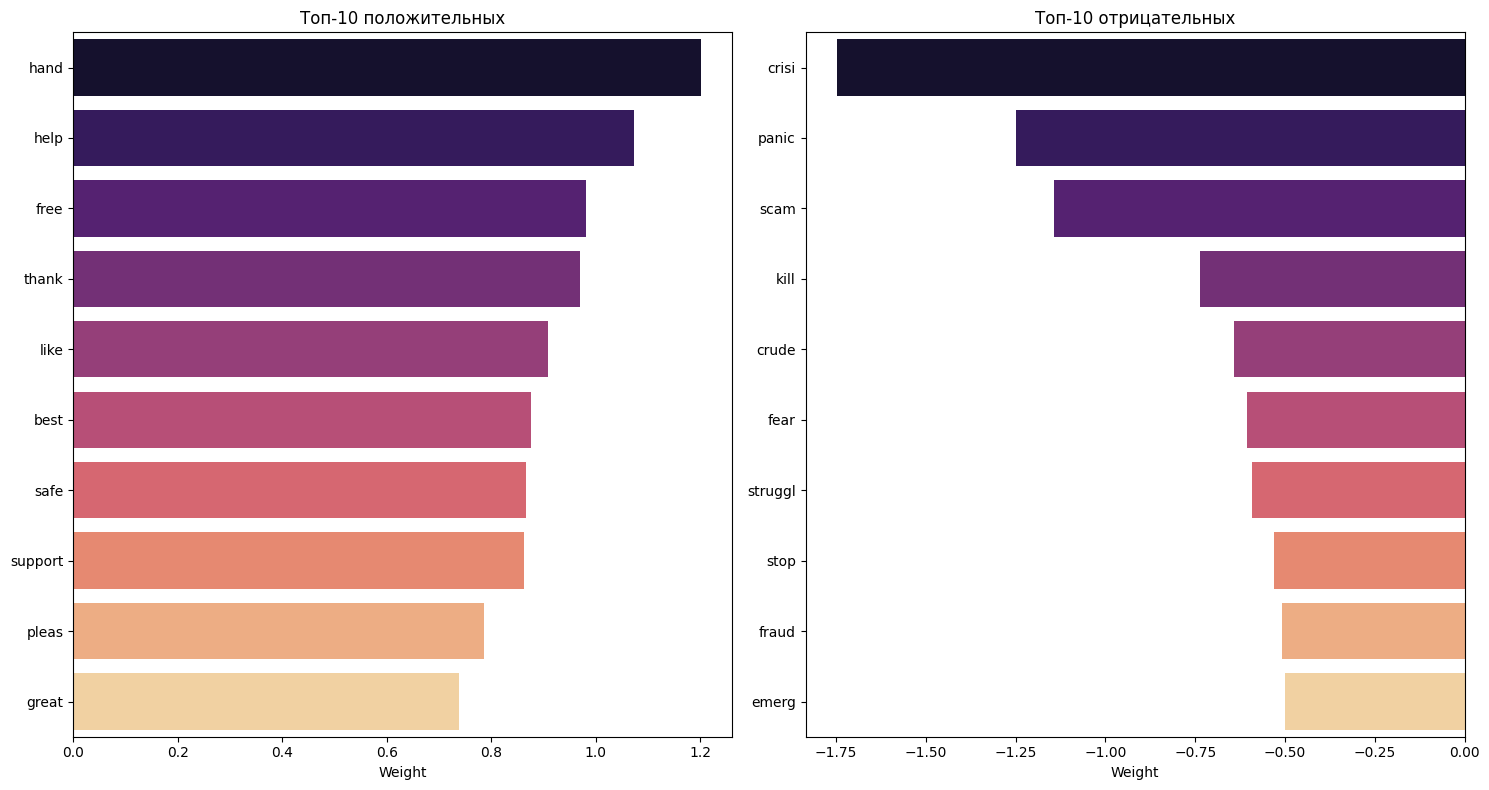

In [41]:
from sklearn.preprocessing import StandardScaler

cv = CountVectorizer(tokenizer=custom_stem_tokenizer, max_features=3700)
X_train_array = cv.fit_transform(X_train).toarray()
X_test_array = cv.transform(X_test).toarray()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_array)
X_test_scaled = scaler.transform(X_test_array)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Train Accuracy:", accuracy_score(y_train, model.predict(X_train_scaled)))
print("Test Accuracy: ", accuracy_score(y_test, model.predict(X_test_scaled)))

feature_names = cv.get_feature_names_out()
weights = model.coef_[0]

top_positive = np.argsort(weights)[-10:][::-1]
top_negative = np.argsort(weights)[:10]

plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
sns.barplot(x=weights[top_positive], y=feature_names[top_positive], palette='magma')
plt.title('Топ-10 положительных')
plt.xlabel('Weight')

plt.subplot(1, 2, 2)
sns.barplot(x=weights[top_negative], y=feature_names[top_negative], palette='magma')
plt.title('Топ-10 отрицательных')
plt.xlabel('Weight')

plt.tight_layout()
plt.show()

**Ответ:** Токены явно разделены на положительные (помощь, благодарность, лучший, безопасность и др.) и отрицательные (паника, кризис, страх и др.)

## Задание 7 Другие признаки (1.5 балла)

Мы были сконцентрированы на работе с текстами твиттов и не использовали другие признаки - имена пользователя, дату и местоположение

Изучите признаки UserName и ScreenName. полезны ли они? Если полезны, то закодируйте их, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

In [42]:
from sklearn.preprocessing import TargetEncoder, StandardScaler
from scipy.sparse import hstack

def frequency_encode(train_df, test_df, column_name):
    freq_map = train_df[column_name].value_counts(normalize=True).to_dict()
    train_encoded = train_df[column_name].map(freq_map).fillna(0).values.reshape(-1, 1)
    test_encoded = test_df[column_name].map(freq_map).fillna(0).values.reshape(-1, 1)
    return train_encoded, test_encoded

cv = CountVectorizer(tokenizer=custom_stem_tokenizer, max_features=3700)
X_train_text = cv.fit_transform(X_train)
X_test_text = cv.transform(X_test)

user_encoder = TargetEncoder(smooth="auto")
X_train_user = user_encoder.fit_transform(
    df.loc[X_train.index, ['UserName']], 
    y_train
)
X_test_user = user_encoder.transform(
    df.loc[X_test.index, ['UserName']]
)


X_train_screen, X_test_screen = frequency_encode(
    df.loc[X_train.index], 
    df.loc[X_test.index], 
    'ScreenName'
)

def prepare_features(text_features, user_feat, screen_feat):
    text_dense = text_features.toarray()
    features = np.hstack([text_dense, user_feat, screen_feat])
    scaler = StandardScaler()
    return scaler.fit_transform(features)

X_train = prepare_features(X_train_text, X_train_user, X_train_screen)
X_test = prepare_features(X_test_text, X_test_user, X_test_screen)

model_combined = LogisticRegression(max_iter=1000)
model_combined.fit(X_train, y_train)

model_base = LogisticRegression(max_iter=1000)
model_base.fit(X_train_text.toarray(), y_train)

combined_test_acc = accuracy_score(y_test, model_combined.predict(X_test))
base_test_acc = accuracy_score(y_test, model_base.predict(X_test_text.toarray()))

print(f"Точность (текст): {base_test_acc:.4f}")
print(f"Точность (текст + UserName и ScreenName): {combined_test_acc:.4f}")

print("\nКоэффициенты новых признаков:")
print(f"UserName (Target Encoding): {model_combined.coef_[0][-2]:.4f}")
print(f"ScreenName (Frequency Encoding): {model_combined.coef_[0][-1]:.4f}")

C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Точность (текст): 0.8683
Точность (текст + UserName и ScreenName): 0.8447

Коэффициенты новых признаков:
UserName (Target Encoding): -0.0560
ScreenName (Frequency Encoding): 0.0000


**Ответ:** Видим, что при кодировании точность несильно просела, а по коэфициентам можем судить, то приз

Изучите признак TweetAt в обучающей выборке: преобразуйте его к типу datetime и нарисуйте его гистограмму с разделением по цвету на основе целевой переменной. Полезен ли он? Если полезен, то закодируйте его, добавьте к матрице с отскалированными признаками, обучите логистическую регрессию, замерьте качество.

C:\Users\Honor\AppData\Local\Temp\ipykernel_18896\2541778563.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["TweetAt"] = pd.to_datetime(df["TweetAt"], errors="coerce")


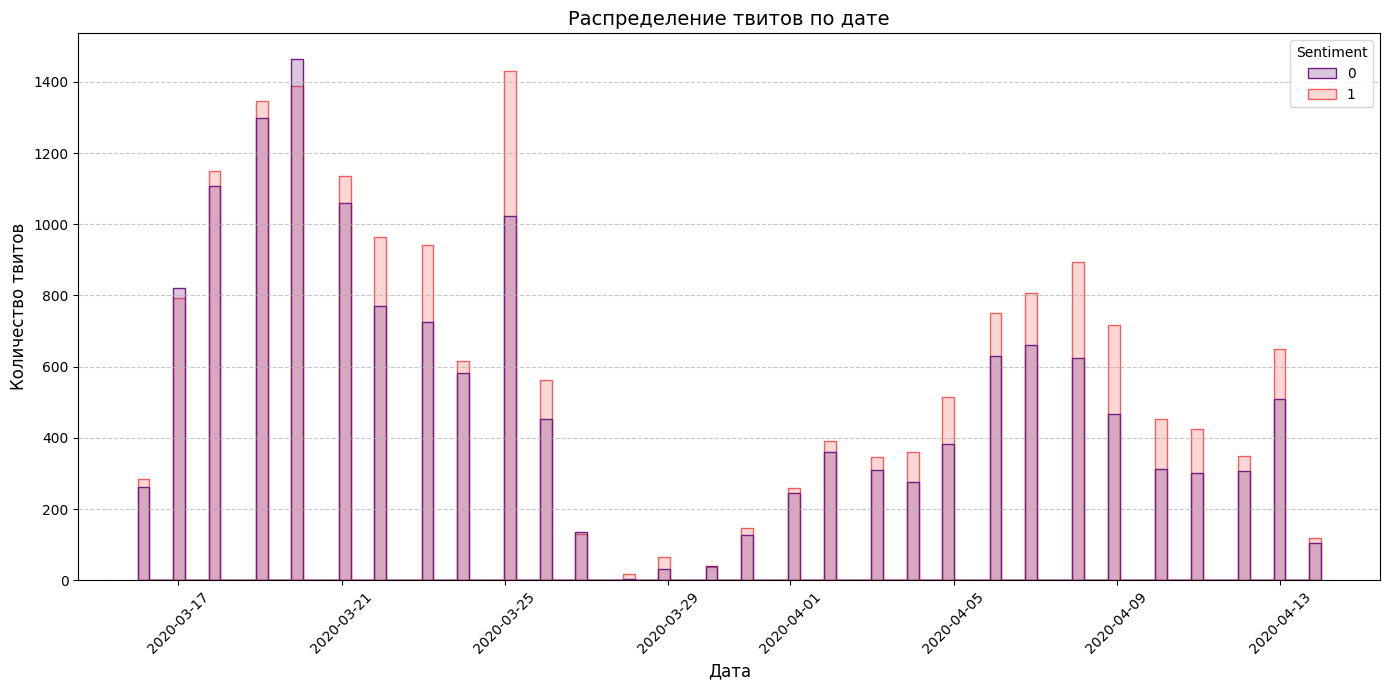

In [43]:
df["TweetAt"] = pd.to_datetime(df["TweetAt"], errors="coerce")
df = df.dropna(subset=["TweetAt"])

plt.figure(figsize=(14, 7))
sns.histplot(
    data=df,
    x="TweetAt",
    hue="Sentiment",
    element="step",
    palette="magma",
    bins=100,
)

plt.title("Распределение твитов по дате", fontsize=14)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Количество твитов", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**Ответ:** # Признак не является информативным, так как в разные периоды времени количество полижтельных и отрицательных твиттов примерно одинаково, а также время публикации полезно было бы использовать при решении другой задачи, а не при выявлении эмоциональной окраски.

Поработайте с признаком Location в обучающей выборке. Сколько уникальных значений?

In [47]:
# -- YOUR CODE HERE --
len(train['Location'].unique())

7949

Постройте гистограмму топ-10 по популярности местоположений (исключая Unknown)

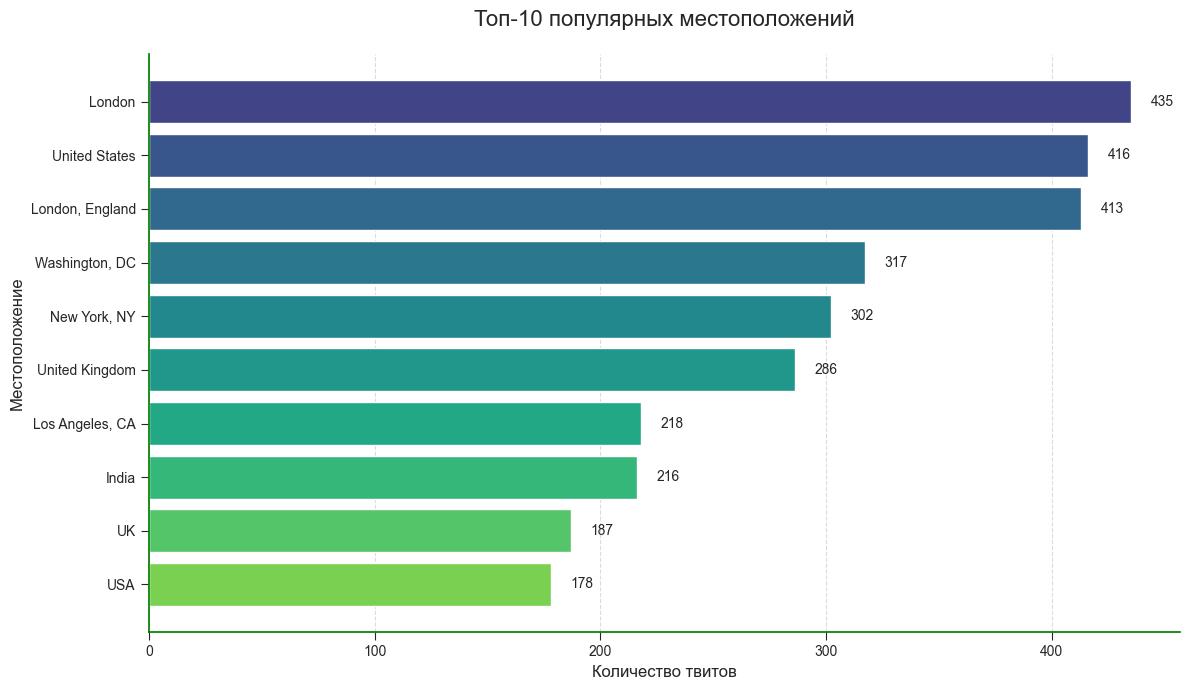

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import numpy as np

filtered_df = df[df["Location"] != "Unknown"]
top_locations = (filtered_df["Location"]
                .value_counts()
                .head(10)
                .sort_values(ascending=True))

plt.style.use('seaborn-v0_8-ticks')
plt.figure(figsize=(12, 7))
ax = plt.gca()

bars = ax.barh(
    top_locations.index,
    top_locations.values,
    color=plt.cm.viridis_r(np.linspace(0.2, 0.8, len(top_locations))),
    edgecolor='white',
    linewidth=1,
    height=0.8
)

for bar in bars:
    width = bar.get_width()
    ax.text(width + max(top_locations.values)*0.02,
            bar.get_y() + bar.get_height()/2,
            f'{width:,}',
            va='center',
            ha='left',
            fontsize=10)

ax.set_title('Топ-10 популярных местоположений', fontsize=16, pad=20)
ax.set_xlabel('Количество твитов', fontsize=12)
ax.set_ylabel('Местоположение', fontsize=12)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f}'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('green')
ax.spines['bottom'].set_color('green')
ax.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Видно, что многие местоположения включают в себя более точное название места, чем другие (Например, у некоторых стоит London, UK; а у некоторых просто UK или United Kingdom).

Создайте новый признак WiderLocation, который содержит самое широкое местоположение (например, из London, UK должно получиться UK). Сколько уникальных категорий теперь? Постройте аналогичную гистограмму.



In [50]:
df["WiderLocation"] = df["Location"].str.split(",").str[-1].str.strip()

filtered_df = df[df["WiderLocation"].notna() & (df["WiderLocation"] != "Unknown")]

print(f"Уникальных категорий после преобразования: {filtered_df['WiderLocation'].nunique()}")

Уникальных категорий после преобразования: 6117


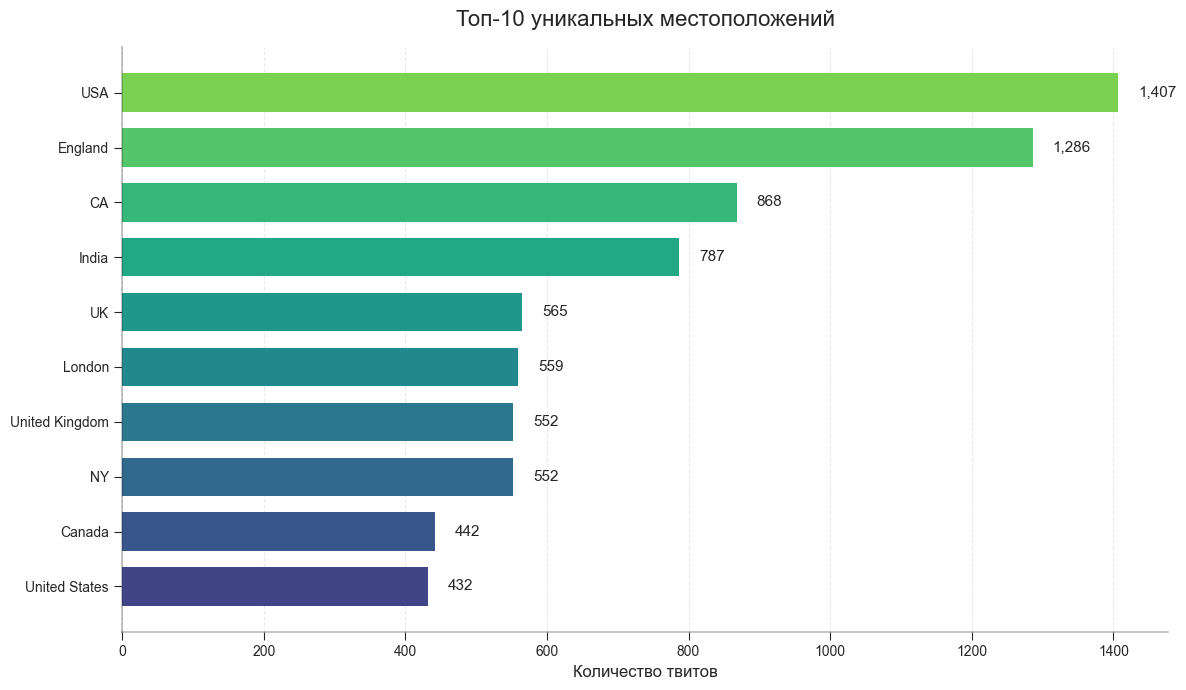

In [51]:
top_locations = (filtered_df['WiderLocation']
                .value_counts()
                .head(10)
                .sort_values(ascending=True))

plt.figure(figsize=(12, 7))
ax = plt.gca()


colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_locations)))

ax.barh(top_locations.index, top_locations.values, color=colors, height=0.7)

for i, (location, count) in enumerate(top_locations.items()):
    ax.text(count + max(top_locations.values)*0.02, 
            i, 
            f'{count:,}',
            va='center',
            ha='left',
            fontsize=11)

ax.set_title('Топ-10 уникальных местоположений', fontsize=16, pad=15)
ax.set_xlabel('Количество твитов', fontsize=12)
ax.set_ylabel('')

# Улучшенные границы
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

# Горизонтальная сетка
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Закодируйте признак WiderLocation с помощью OHE таким образом, чтобы создались только столбцы для местоположений, которые встречаются более одного раза. Сколько таких значений?

In [52]:
frequent_locations = df['WiderLocation'].value_counts().loc[lambda x: x > 1]
print(f"Количество часто встречающихся локаций (>1): {len(frequent_locations)}")

location_ohe = (
    df.loc[df['WiderLocation'].isin(frequent_locations.index), 'WiderLocation']
    .pipe(pd.get_dummies, prefix='Location')
)

Количество часто встречающихся локаций (>1): 1308


Добавьте этот признак к матрице отскалированных текстовых признаков, обучите логистическую регрессию, замерьте качество. Как оно изменилось? Оказался ли признак полезным?


*Подсказка:* используйте параметр `categories` в энкодере.

In [53]:
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder

vectorizer = TfidfVectorizer(tokenizer=custom_stem_tokenizer)
X_text = vectorizer.fit_transform(df['OriginalTweet'])

location_counts = df["WiderLocation"].value_counts()
locations_over_one = location_counts[location_counts > 1].index
ohe_encoder = OneHotEncoder(categories=[locations_over_one.tolist()], 
                           handle_unknown='ignore',
                           sparse_output=True)
X_location = ohe_encoder.fit_transform(df[["WiderLocation"]])

X_combined = sparse.hstack([X_text, X_location], format='csr')

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, 
    df['Sentiment'],
    test_size=0.3,
    random_state=0
)

model_text = LogisticRegression(max_iter=1000).fit(X_train[:, :X_text.shape[1]], y_train)
model_combined = LogisticRegression(max_iter=1000).fit(X_train, y_train)


acc_text = accuracy_score(y_test, model_text.predict(X_test[:, :X_text.shape[1]]))
acc_combined = accuracy_score(y_test, model_combined.predict(X_test))
coef = model_combined.coef_[0][-len(locations_over_one):].mean()

print(f"Точность (только текст): {acc_text:.4f}")
print(f"Точность (текст + локации): {acc_combined:.4f}")
print(f"Коэффициент для локаций: {coef:.4f}")

C:\Users\Honor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Точность (только текст): 0.8565
Точность (текст + локации): 0.8528
Коэффициент для локаций: 0.0135


**Ответ:** Точност изменилась несильно, но признак полезным не кажется, потому что страна должна мало влиять на эмоциоона